# Stellar Classification and Supervised Learning
This notebook demonstrates how to build, train, and evaluate multiple models (both traditional ML and PyTorch Neural Networks) using our custom `stellar_classification` package.

In [1]:
import sys, os, gc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



#sistemare il warning di LightGBM fa creare warning a tutti gli altri modelli addestrati senza
#feature name, quindi meglio ingorarli
import warnings
warnings.filterwarnings("ignore", category=UserWarning)


sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'stellar_classification')))
import stellar_classification as sc
from sklearn.metrics import accuracy_score
from stellar_classification.models.trees import SimpleRandomForest

# Enable garbage collection
gc.enable()
gc.collect()

/home/ubuntu/miniconda3/envs/comp_phys/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


20

First few rows:


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,...,spec_obj_ID,class,redshift,plate,MJD,fiber_ID,u_g,g_r,r_i,i_z
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,...,6.543777e+18,GALAXY,0.634794,5812,56354,171,1.60352,1.88029,1.22928,0.37202
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,...,1.176014e+19,GALAXY,0.779136,10445,58158,427,1.94571,0.24744,1.41632,-0.44615
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,...,5.152200e+18,GALAXY,0.644195,4576,55592,299,2.59918,2.05413,1.26119,0.40030
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,...,1.030107e+19,GALAXY,0.932346,9149,58039,775,-1.63974,2.16494,1.10708,1.25444
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,...,6.891865e+18,GALAXY,0.116123,6121,56187,842,1.85690,1.08281,0.52036,0.43250



Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  str    
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
 18  u_g          100000 non-

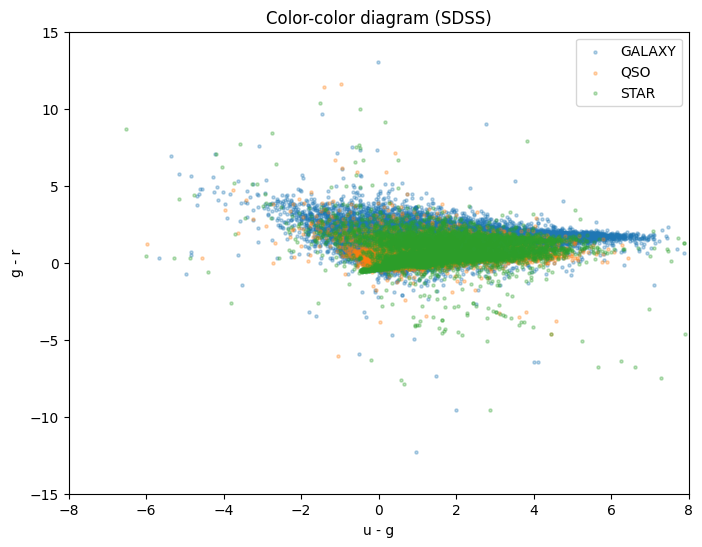

In [2]:
# Load dataset
data_path = '../stellar_classification/stellar_classification/data/star_classification.csv'
star = pd.read_csv(data_path)

# -------- Color indexes ----------
star["u_g"] = star["u"] - star["g"]
star["g_r"] = star["g"] - star["r"]
star["r_i"] = star["r"] - star["i"]
star["i_z"] = star["i"] - star["z"]


print("First few rows:")
display(star.head())

print("\nData Info:")
star.info()

print("\nNull Values:")
print(star.isnull().sum())

print("\nClass Distribution:")
print(star["class"].value_counts(normalize=True) * 100)

plt.figure(figsize=(8,6))

for c in star['class'].unique():
    subset = star[star['class'] == c]
    plt.scatter(subset['u_g'], subset['g_r'],
                label=c,
                s=5,
                alpha=0.3)
    plt.xlim(-8, 8)
    plt.ylim(-15, 15)

plt.xlabel('u - g')
plt.ylabel('g - r')
plt.legend()
plt.title('Color-color diagram (SDSS)')
plt.show()



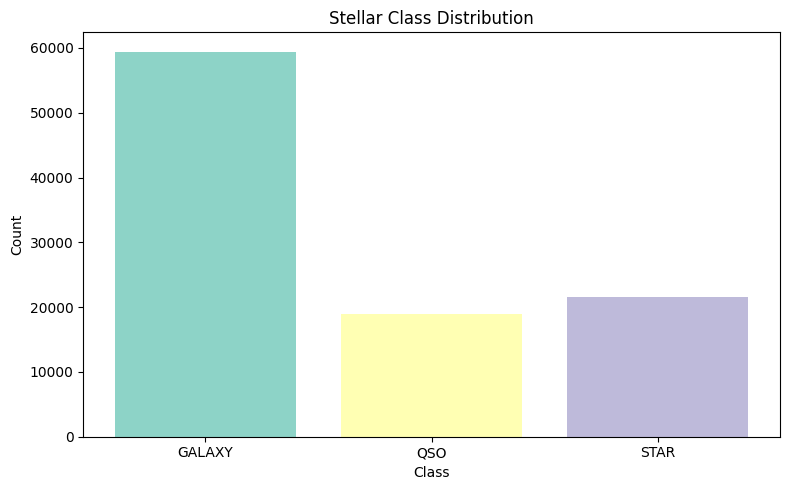

In [3]:
# Visualize Class Distribution
sc.plot_class_distribution(star['class'], title="Stellar Class Distribution")


In [4]:
# Preprocessing: Apply outlier removal, splits, standardization, and SMOTE
X_train, X_val, X_test, y_train, y_val, y_test, label_encoder, scaler, feature_names = sc.prepare_splits(
    star, 
    target_col='class', 
    test_size=0.2, 
    val_ratio=0.25, 
    random_state=42, 
    apply_outlier_removal=True
)

class_names = list(label_encoder.classes_)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")

print(feature_names)

Outliers removed: 8,715 rows  (91,285 remain)
X_train shape: (97032, 13)
X_val shape: (18257, 13)
X_test shape: (18257, 13)
['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'plate', 'MJD', 'u_g', 'g_r', 'r_i', 'i_z']


In [5]:
# Convert numpy arrays to PyTorch DataLoaders
train_loader, val_loader, test_loader = sc.to_dataloaders(
    X_train, y_train, 
    X_val, y_val, 
    X_test, y_test, 
    batch_size=64
)


print("DataLoaders created.")


DataLoaders created.


## Random Forest and Extra Trees 

In [6]:
import importlib, sys
to_remove = [k for k in sys.modules if 'stellar_classification' in k]
for k in to_remove:
    del sys.modules[k]
import stellar_classification as sc

In [6]:
#train su random forest ed extra trees
models = sc.train_trees_with_tuning(X_train, y_train, X_val, y_val, n_iter=5, cv=3)
rf_model = models['Random Forest']
et_model = models['Extra Trees']

Random Forest best params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_samples': 0.7, 'max_features': 0.5, 'max_depth': 20}
  [Train] Acc=97.97%  F1=0.9798
  [Val] Acc=90.26%  F1=0.8763
Extra Trees best params: {'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': None}
  [Train] Acc=99.64%  F1=0.9964
  [Val] Acc=90.55%  F1=0.8787


In [7]:
#evaluate test set
rf_metrics = sc.evaluate_test_set(y_test, rf_model.predict(X_test), 'Random Forest')
et_metrics = sc.evaluate_test_set(y_test, et_model.predict(X_test), 'Extra Trees')

sc.print_metrics(rf_metrics)
sc.print_metrics(et_metrics)


Random Forest:
  Accuracy  : 90.71%
  Precision: 0.8788
  Recall   : 0.8853
  F1       : 0.8815
  Confusion Matrix:
[[10165   353   263]
 [  213  3110   225]
 [  272   370  3286]]

Extra Trees:
  Accuracy  : 90.73%
  Precision: 0.8802
  Recall   : 0.8826
  F1       : 0.8807
  Confusion Matrix:
[[10218   345   218]
 [  225  3102   221]
 [  291   393  3244]]


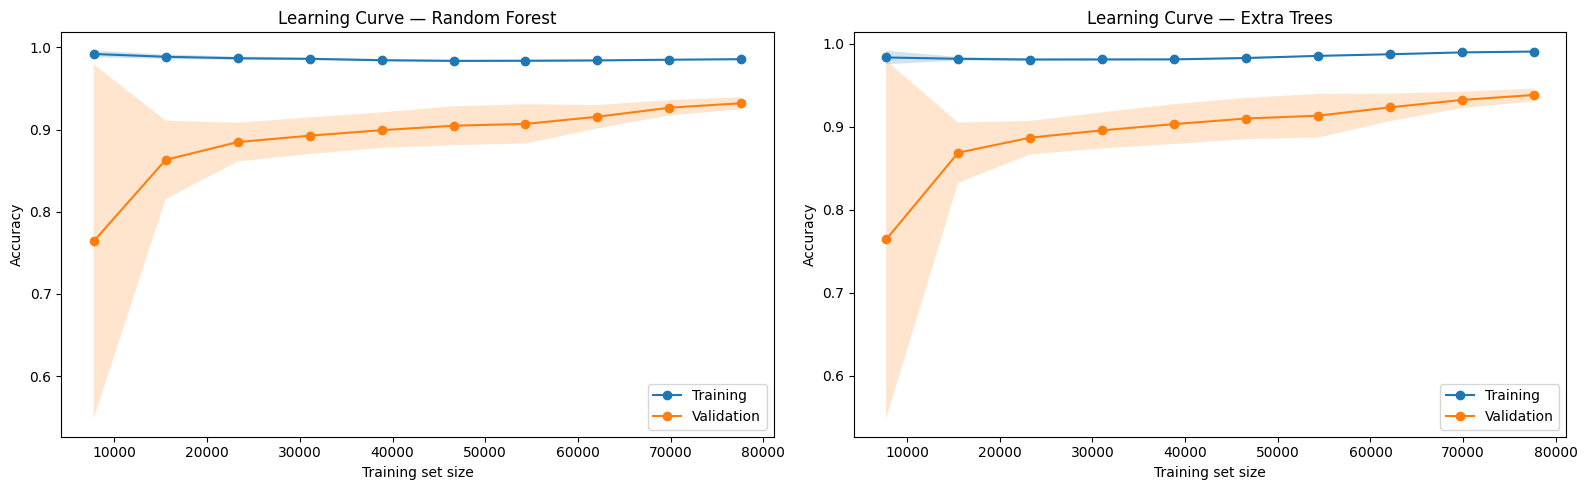

In [8]:
from stellar_classification.models.trees import SimpleRandomForest, SimpleExtraTrees

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sc.plot_learning_curve(
    SimpleRandomForest(**rf_model.get_params()),
    X_train, y_train,
    title='Learning Curve — Random Forest',
    ax=axes[0]
)

sc.plot_learning_curve(
    SimpleExtraTrees(**et_model.get_params()),
    X_train, y_train,
    title='Learning Curve — Extra Trees',
    ax=axes[1]
)

plt.tight_layout()
plt.show()


se le curve iniziano a convergere significa che ipoteticamente l'overfitting è dovuto ad una insufficienza di dati. Ed è il caso in cui ci troviamo. Se cosi non fosse invece, allora l'overfitting sarebbe causato da una complessità del modello, possiamo quindi concludere che l'overfitting non è puramente strutturale.

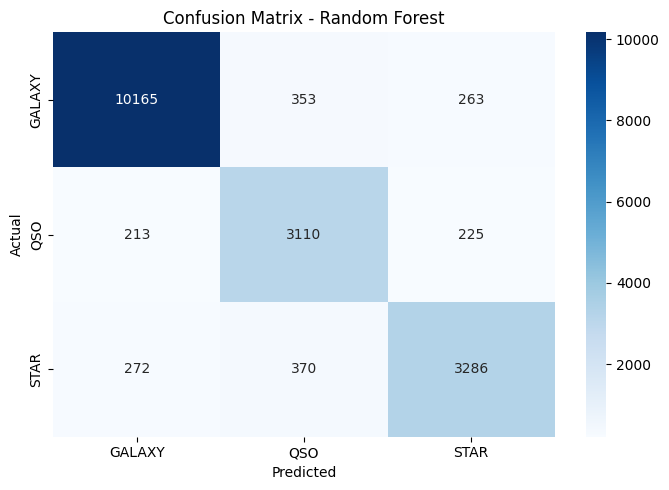

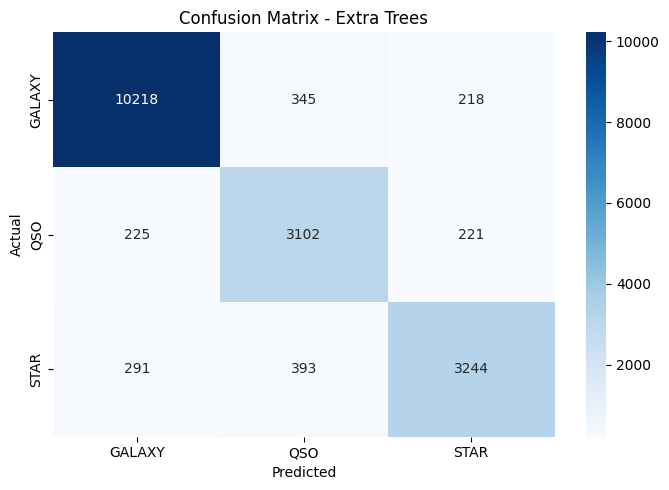

In [9]:
#matrici di confusione per i due modelli 

sc.plot_confusion_matrix(rf_metrics['confusion_matrix'], class_names=class_names,
                         title='Confusion Matrix - Random Forest')
sc.plot_confusion_matrix(et_metrics['confusion_matrix'], class_names=class_names,
                         title='Confusion Matrix - Extra Trees')

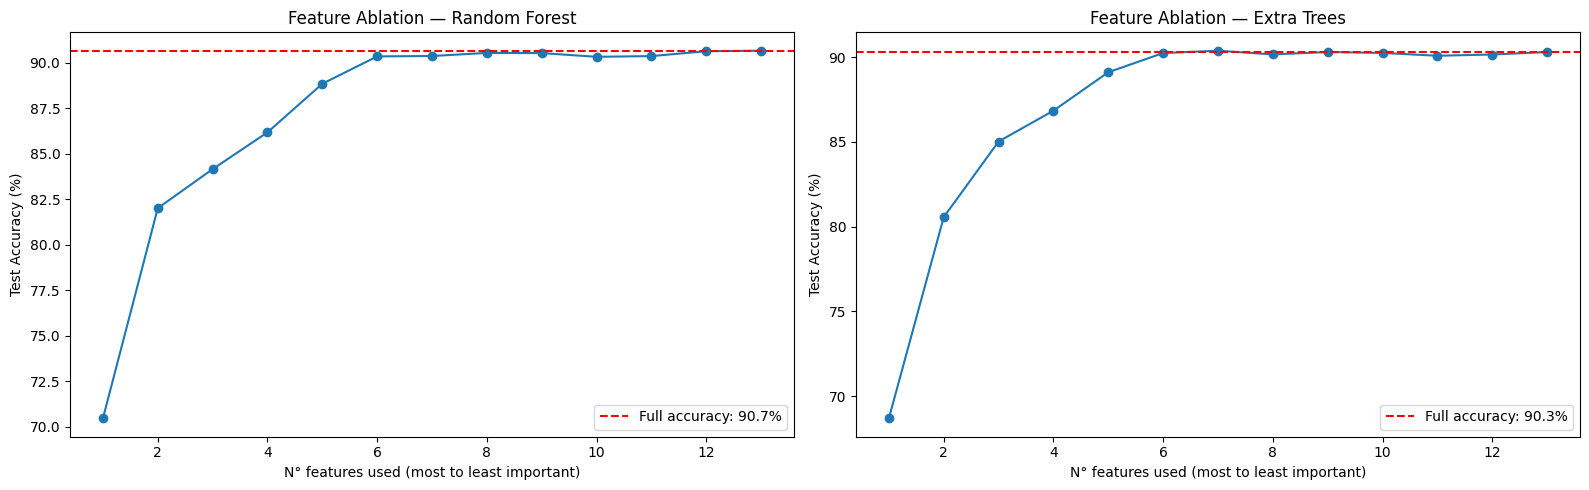

In [10]:
# Feature Ablation

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sc.plot_feature_ablation(rf_model, X_train, X_test, y_train, y_test,
                         feature_names, 
                         title='Feature Ablation — Random Forest',
                         ax=axes[0])

sc.plot_feature_ablation(et_model, X_train, X_test, y_train, y_test,
                         feature_names,
                         title='Feature Ablation — Extra Trees',
                         ax=axes[1])

plt.tight_layout()
plt.show()

           RANDOM FOREST — Prediction & Error Map


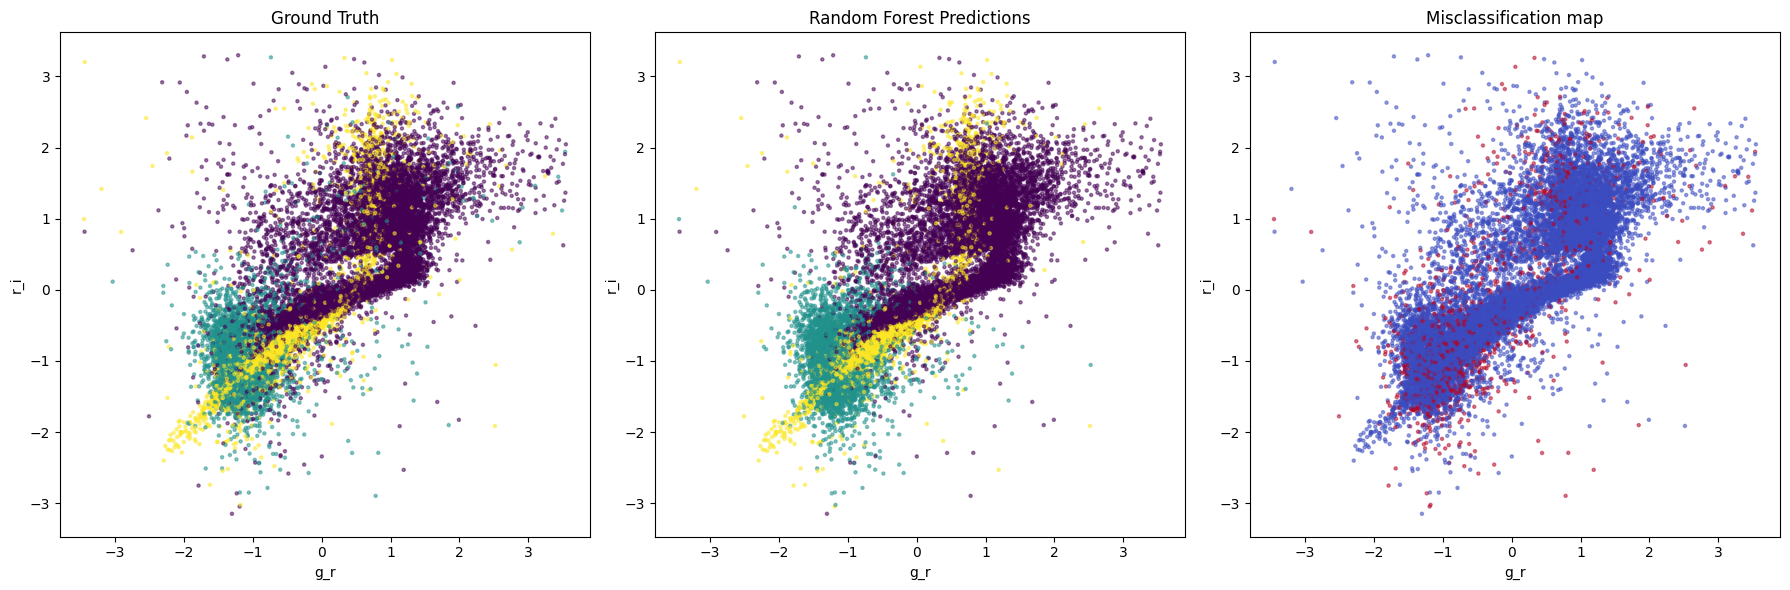

           EXTRA TREES — Prediction & Error Map


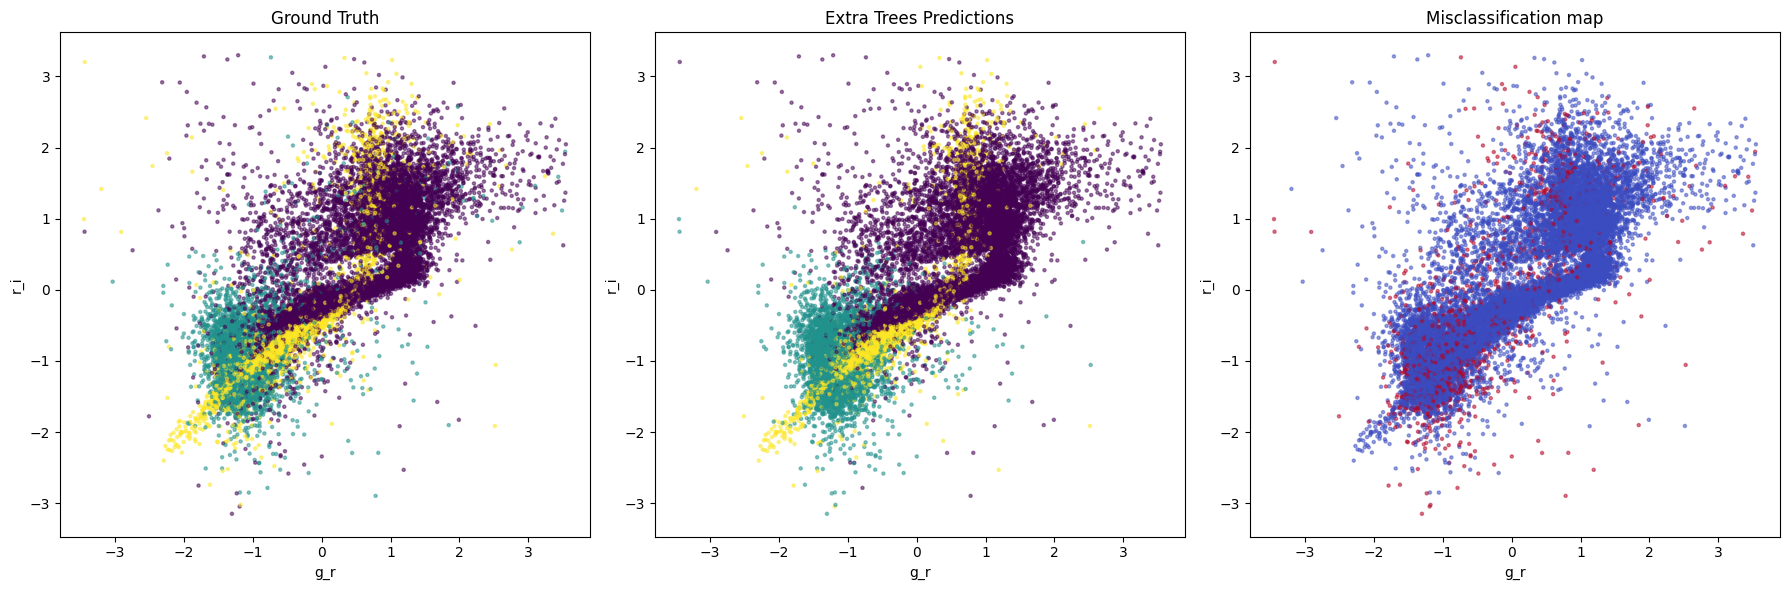

In [11]:
X_test_df = pd.DataFrame(X_test, columns=feature_names)

y_test_pred_rf = rf_model.predict(X_test)
y_test_pred_et = et_model.predict(X_test)

print("           RANDOM FOREST — Prediction & Error Map")
sc.plot_prediction_and_error_map(
    X_test_df, y_test, y_test_pred_rf,
    feature_x="g_r", feature_y="r_i",
    title_prefix="Random Forest"
)
print("           EXTRA TREES — Prediction & Error Map")
sc.plot_prediction_and_error_map(
    X_test_df, y_test, y_test_pred_et,
    feature_x="g_r", feature_y="r_i",
    title_prefix="Extra Trees"
)

           RANDOM FOREST — Prediction & Error Map


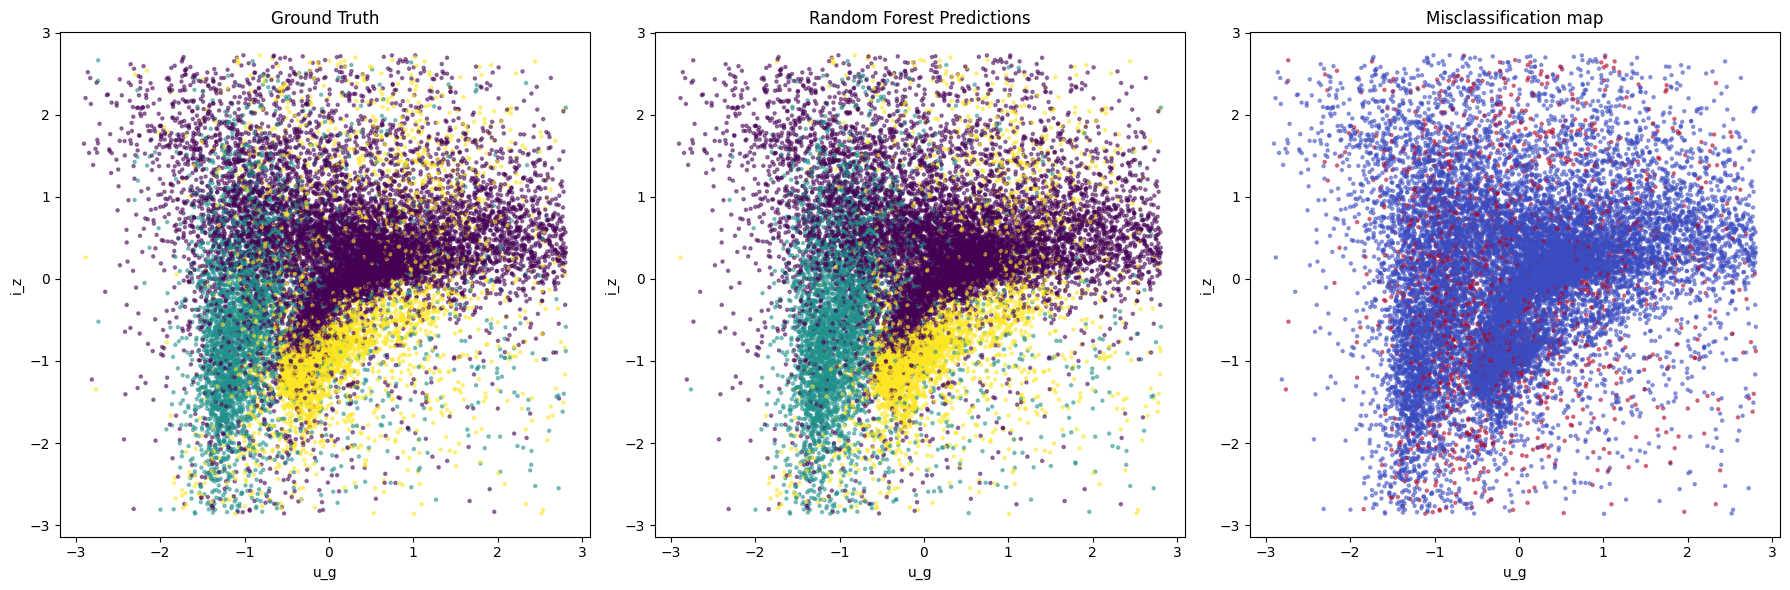

           EXTRA TREES — Prediction & Error Map


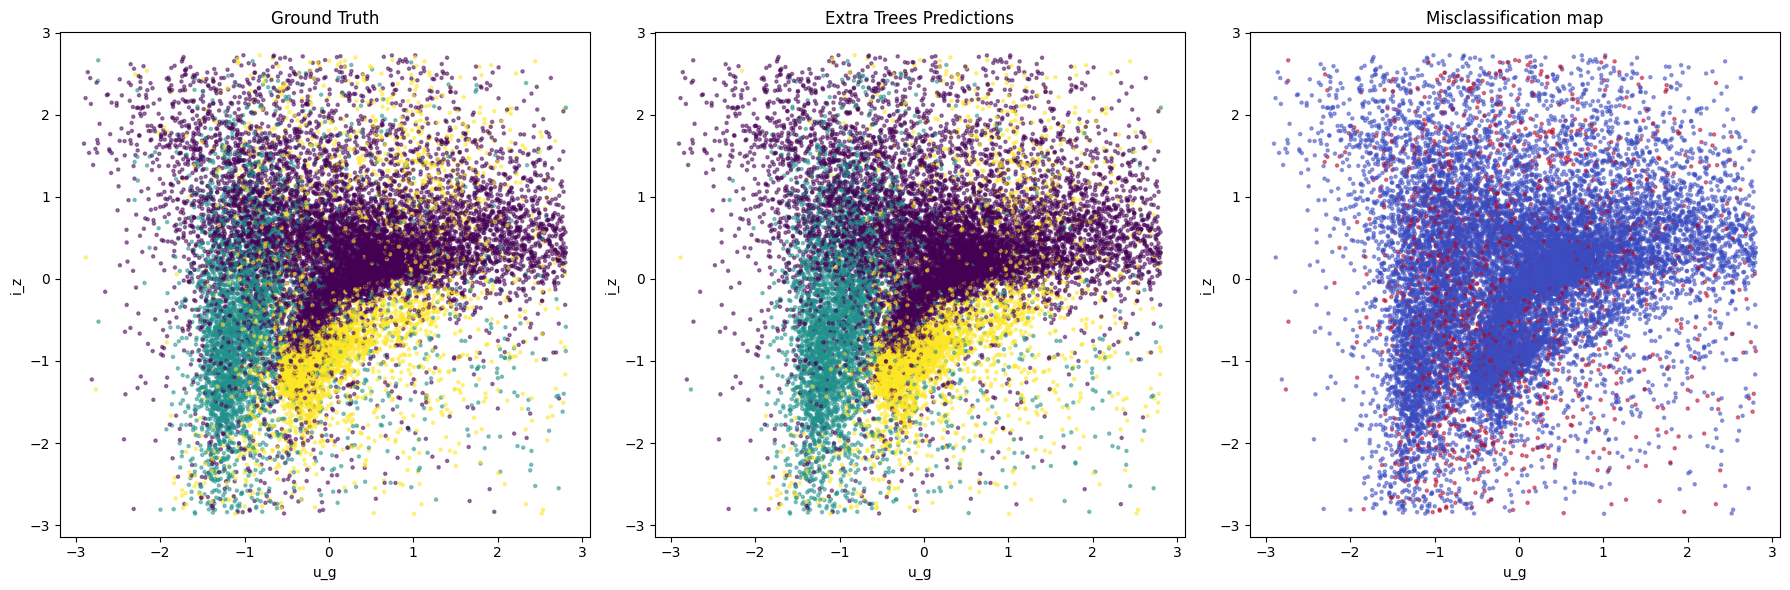

In [12]:
print("           RANDOM FOREST — Prediction & Error Map")
sc.plot_prediction_and_error_map(
    X_test_df, y_test, y_test_pred_rf,
    feature_x="u_g", feature_y="i_z",
    title_prefix="Random Forest"
)
print("           EXTRA TREES — Prediction & Error Map")
sc.plot_prediction_and_error_map(
    X_test_df, y_test, y_test_pred_et,
    feature_x="u_g", feature_y="i_z",
    title_prefix="Extra Trees"
)

           RANDOM FOREST 


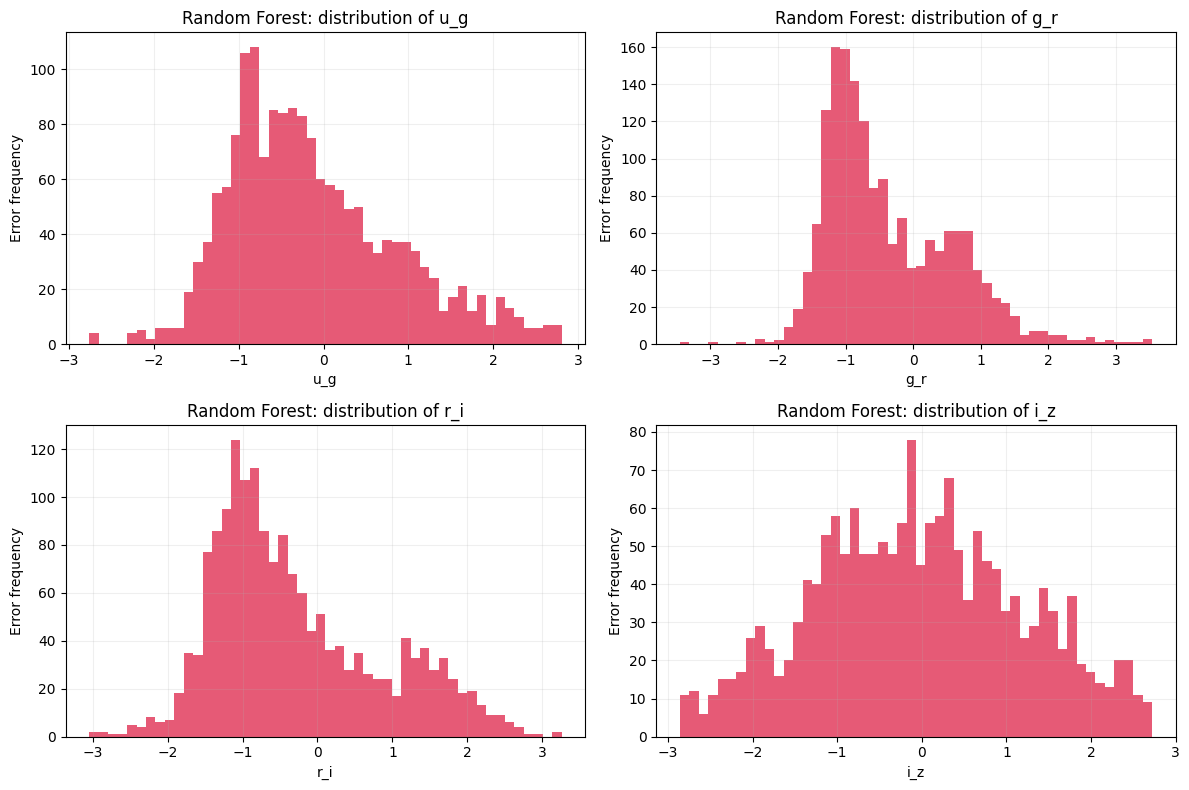

           EXTRA TREES 


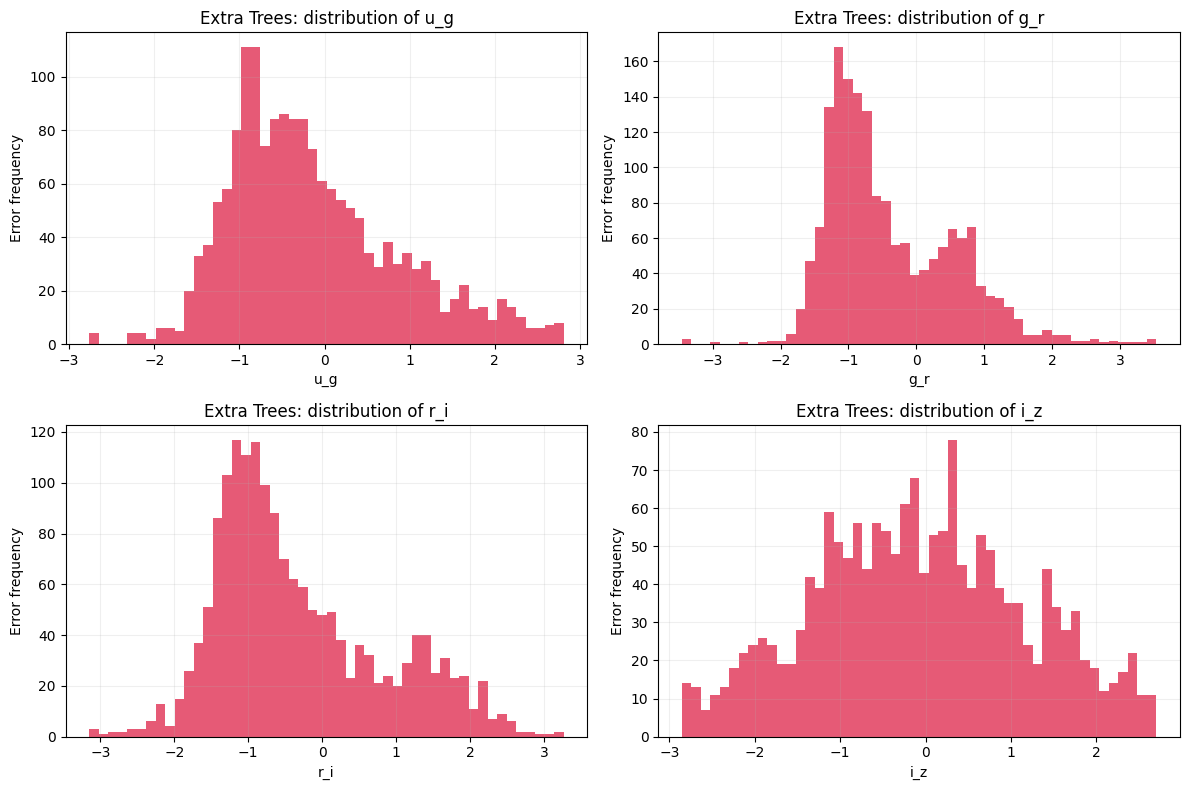

In [13]:
print("           RANDOM FOREST ")
sc.plot_misclassified_feature_distributions(
    X_test_df, y_test, y_test_pred_rf,
    features=["u_g", "g_r", "r_i", "i_z"],
    title_prefix="Random Forest"
)

print("           EXTRA TREES ")
sc.plot_misclassified_feature_distributions(
    X_test_df, y_test, y_test_pred_et,
    features=["u_g", "g_r", "r_i", "i_z"],
    title_prefix="Extra Trees"
)

           RANDOM FOREST — Feature Importance


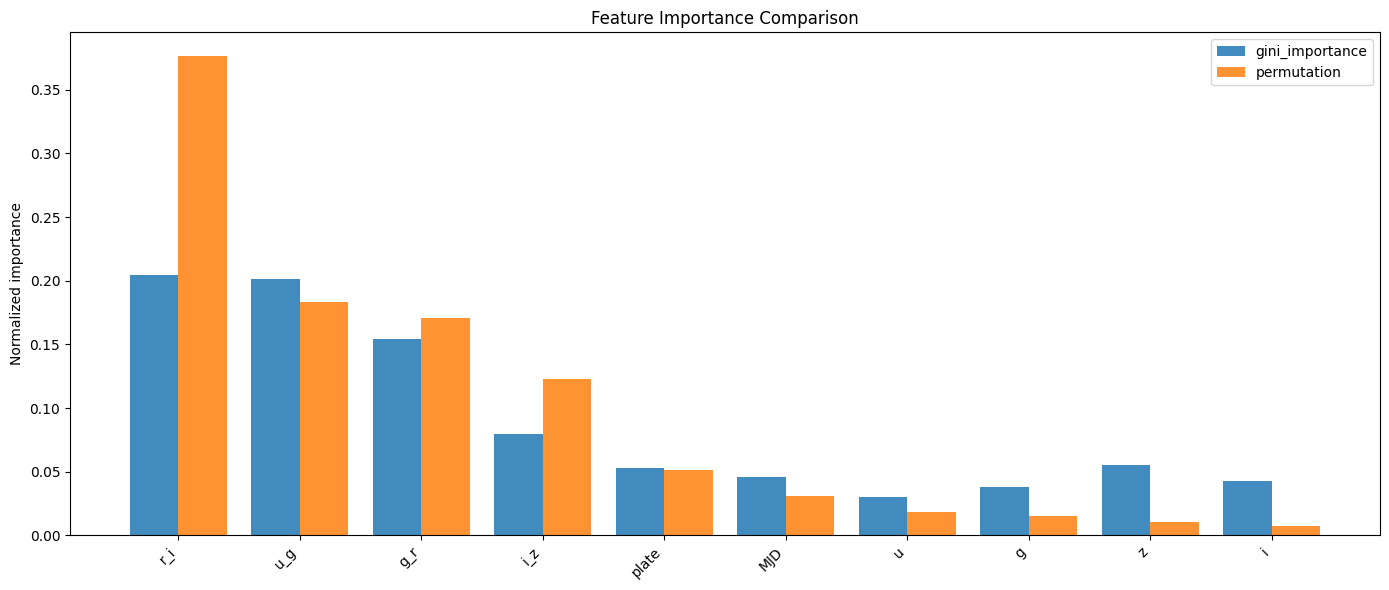


 Feature Importance Scores:


,gini_importance,permutation
r_i,0.204640,0.376297
u_g,0.201318,0.183458
g_r,0.154618,0.170413
i_z,0.079941,0.122871
plate,0.052850,0.051051
MJD,0.045813,0.030729
u,0.030122,0.018442
g,0.038263,0.015451
z,0.055080,0.010527
i,0.042685,0.007027


           EXTRA TREES — Feature Importance


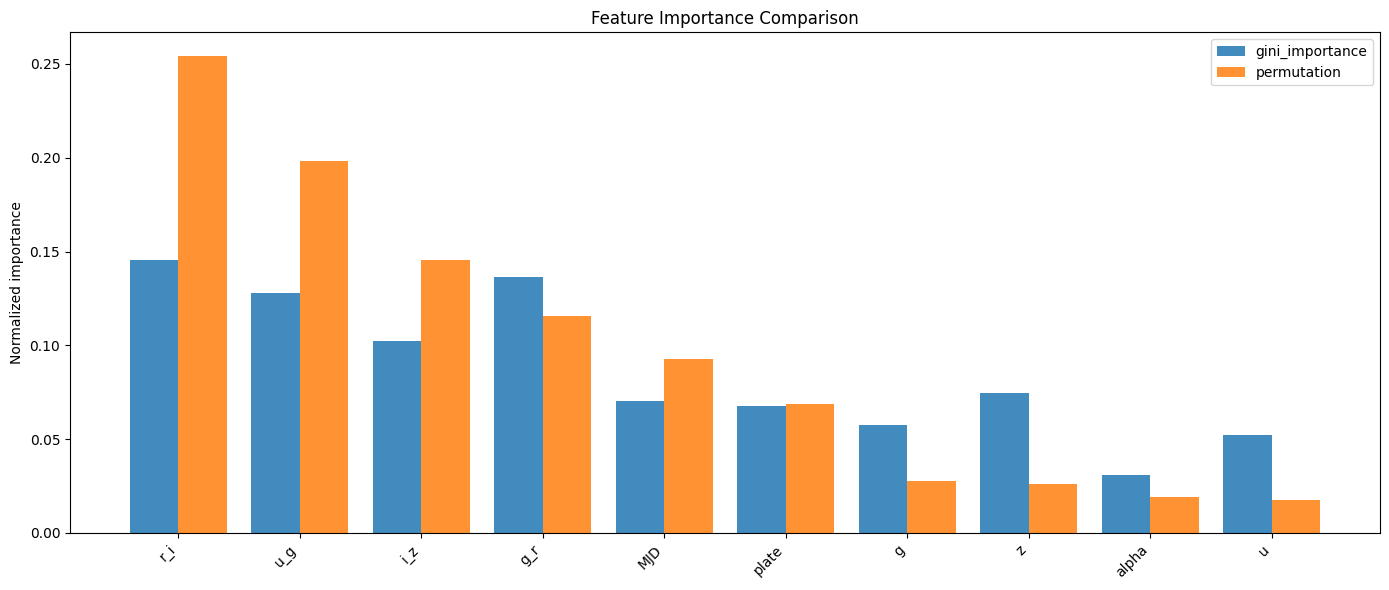


 Feature Importance Scores:


,gini_importance,permutation
r_i,0.145436,0.254168
u_g,0.127828,0.198286
i_z,0.102239,0.145509
g_r,0.136620,0.115737
MJD,0.070426,0.092515
plate,0.067641,0.068905
g,0.057296,0.027925
z,0.074543,0.026031
alpha,0.030817,0.019170
u,0.052335,0.017836


In [14]:
importance_functions= {
    "gini_importance": lambda m: m.feature_importances_
}



print("           RANDOM FOREST — Feature Importance")
df_imp_rf = sc.plot_feature_importance(
    rf_model,
    feature_names,
    importance_functions=importance_functions,
    
    use_permutation=True,
    X_test=X_test,
    y_test=y_test,
    
    top_k=10,
    sort_by="permutation"
)



print("           EXTRA TREES — Feature Importance")
df_imp_et = sc.plot_feature_importance(
    et_model,
    feature_names,
    importance_functions=importance_functions,
    
    use_permutation=True,
    X_test=X_test,
    y_test=y_test,
    
    top_k=10,
    sort_by="permutation"
)